# 02a — Colab Setup, Tar Extraction & Dataset Sanity Checks

## 0. Mount Drive, fetch the shared module, extract the tar

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.3 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path

# UPDATE THIS to wherever you uploaded yolo_common_colab.py on Drive
SCRIPTS_DIR = Path("/content/drive/Shareddrives/Computer Vision Final Project/Modeling/YOLO")
sys.path.insert(0, str(SCRIPTS_DIR))

from yolo_common_colab import *

data_yaml_path, data_yaml, unified_classes, train_image_paths, val_image_paths, test_image_paths = load_dataset()

Extracting /content/drive/Shareddrives/Computer Vision Final Project/Data/tar_datasets/fv40_merged.tar (3017 MB) -> /content/dataset...
34929 entries in the tar
  2000/34929  (46 files/s, ~11.9 min left)
  4000/34929  (89 files/s, ~5.8 min left)
  6000/34929  (128 files/s, ~3.8 min left)
  8000/34929  (164 files/s, ~2.7 min left)
  10000/34929  (201 files/s, ~2.1 min left)
  12000/34929  (238 files/s, ~1.6 min left)
  14000/34929  (274 files/s, ~1.3 min left)
  16000/34929  (310 files/s, ~1.0 min left)
  18000/34929  (294 files/s, ~1.0 min left)
  20000/34929  (325 files/s, ~0.8 min left)
  22000/34929  (357 files/s, ~0.6 min left)
  24000/34929  (388 files/s, ~0.5 min left)
  26000/34929  (419 files/s, ~0.4 min left)
  28000/34929  (450 files/s, ~0.3 min left)
  30000/34929  (480 files/s, ~0.2 min left)
  32000/34929  (511 files/s, ~0.1 min left)
  34000/34929  (541 files/s, ~0.0 min left)
  34929/34929  (555 files/s, ~0.0 min left)
Extraction complete in 1.0 min.
Extracting /content/

## 0.6 Sanity-check the dataset

In [3]:
from collections import Counter
import concurrent.futures as cf
import time

def count_classes_in_label(img_path):
    label_path = img2label_path(img_path)
    counts = Counter()
    if not label_path.exists():
        return counts
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1
    return counts

class_counts = Counter()
start = time.time()
with cf.ThreadPoolExecutor(max_workers=32) as ex:
    for i, counts in enumerate(ex.map(count_classes_in_label, train_image_paths), start=1):
        class_counts.update(counts)
        if i % 5000 == 0 or i == len(train_image_paths):
            elapsed = time.time() - start
            print(f"  {i}/{len(train_image_paths)}  ({i/elapsed:.0f} files/s)")
print(f"Done in {time.time() - start:.1f}s -- should be dramatically faster than the Drive-mounted version, since this reads from /content now.")


  5000/23317  (4309 files/s)
  10000/23317  (5165 files/s)
  15000/23317  (5475 files/s)
  20000/23317  (5816 files/s)
  23317/23317  (5981 files/s)
Done in 3.9s -- should be dramatically faster than the Drive-mounted version, since this reads from /content now.


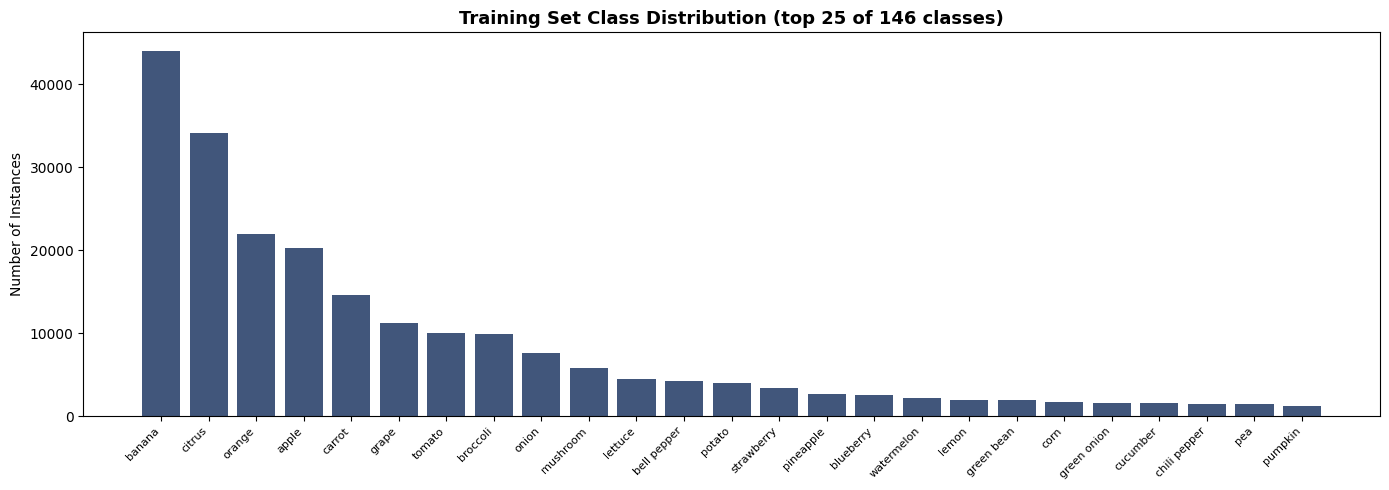

Most common class: banana (44027 instances)
Rarest class: long beans (6 instances)
Imbalance ratio: 7337.8x



In [4]:
counts_by_id = [class_counts.get(i, 0) for i in range(len(unified_classes))]
nonzero = [(unified_classes[i], c) for i, c in enumerate(counts_by_id) if c > 0]
nonzero.sort(key=lambda x: x[1], reverse=True)

top_n = 25
fig, ax = plt.subplots(figsize=(14, 5))
show = nonzero[:top_n]
ax.bar([n for n, _ in show], [c for _, c in show], color="#1F3864", alpha=0.85)
ax.set_title(f"Training Set Class Distribution (top {top_n} of {len(nonzero)} classes)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Instances")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

max_c, min_c = max(counts_by_id), min(c for c in counts_by_id if c > 0)
print(f"Most common class: {nonzero[0][0]} ({max_c} instances)")
print(f"Rarest class: {nonzero[-1][0]} ({min_c} instances)")
print(f"Imbalance ratio: {max_c/min_c:.1f}x")
if max_c / min_c > 10:
    print("\nWARNING: severe class imbalance detected -- worth flagging in the report.")


## Ground-truth visualization

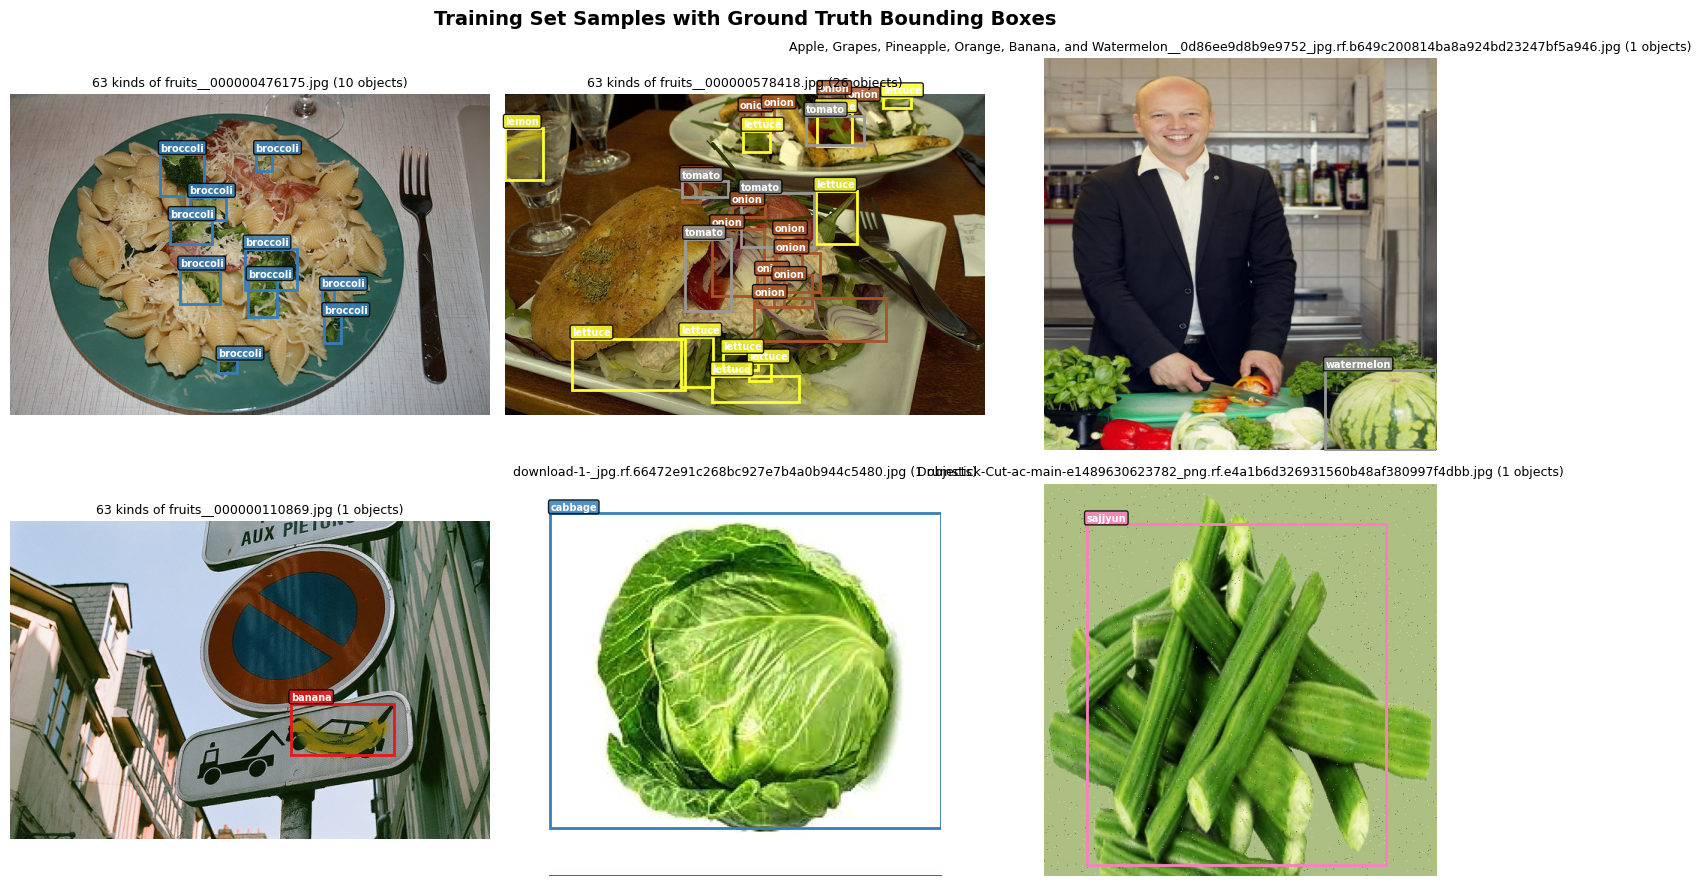

In [5]:
import random
class_colors = get_class_colors(unified_classes)

random.seed(0)
sample_imgs = random.sample(train_image_paths, 6)  # random, not sorted[:6] -- augmented copies share filename prefixes

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Training Set Samples with Ground Truth Bounding Boxes", fontsize=14, fontweight="bold")
for ax, img_path in zip(axes.flat, sample_imgs):
    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size
    ax.imshow(img)
    label_path = img2label_path(img_path)
    boxes = [(c, x, y, w, h, None) for c, x, y, w, h in parse_yolo_label(label_path, img_w, img_h)]
    draw_boxes(ax, boxes, unified_classes, class_colors, f"{img_path.name} ({len(boxes)} objects)")
plt.tight_layout()
plt.show()
